## FinShield AI Assistant Part 3

#### Environment Setup & Prerequisite Validation

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "scikit-learn", "lightgbm", "statsmodels", "shap", "joblib",
    "--break-system-packages"])

CompletedProcess(args=['C:\\Users\\udays\\anaconda3\\python.exe', '-m', 'pip', 'install', '-q', 'pandas', 'numpy', 'scikit-learn', 'lightgbm', 'statsmodels', 'shap', 'joblib', '--break-system-packages'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import joblib
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

**Check that Part 1 & Part 2 have already been run**

In [3]:
required = [
    "Data/processed/customer_profile_clean.csv",
    "Data/processed/financial_transactions_clean.csv",
    "Data/processed/credit_history_clean.csv",
    "Data/raw/economic_indicators.csv",
    "Models/risk_classifier_rf.pkl",
    "outputs/fraud_scores.csv",
    "outputs/market_forecasts.csv",
    "outputs/company_sentiment_impact.csv",
]
missing = [f for f in required if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(
        "Missing output(s): " + ", ".join(missing) +
        "\n\nRun the Part 1 notebook, then the Part 2 notebook, first — in this same folder."
    )
print("All Part 1 & 2 files found & ready to continue.")

All Part 1 & 2 files found & ready to continue.


**Load Customer Data & Trained Risk Model**

In [4]:
customers = pd.read_csv("Data/processed/customer_profile_clean.csv")
txn = pd.read_csv("Data/processed/financial_transactions_clean.csv")
credit = pd.read_csv("Data/processed/credit_history_clean.csv")
economic_indicators = pd.read_csv("Data/raw/economic_indicators.csv")
df = customers.merge(txn, on="customer_id").merge(credit, on="customer_id")

rf = joblib.load("Models/risk_classifier_rf.pkl")
label_names = {0:"Low", 1:"Medium", 2:"High", 3:"Critical"}
os.makedirs("outputs", exist_ok=True)
print(f"Loaded {len(df):,} customers and the trained Random Forest.")

Loaded 60,000 customers and the trained Random Forest.


### Part 3: Intelligence, Scoring & Explainability

**Rebuild the Part 2 Feature Matrix**

In [5]:
from sklearn.preprocessing import LabelEncoder

feature_cols = ["age","employment_years","num_children","monthly_income","monthly_expense","savings_amount","investment_amount","loan_amount",
                "emi_amount","credit_usage_pct","transaction_count_monthly","credit_score","previous_loans","late_payments","credit_card_count",
                "loan_duration_months"]
cat_cols = ["gender","occupation","education","city_tier","family_status"]

X = df[feature_cols + cat_cols].copy()
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))
print("Feature matrix rebuilt:", X.shape)

Feature matrix rebuilt: (60000, 21)


**Load Fraud, Market & Sentiment Outputs**

In [6]:
fraud_scores = pd.read_csv("outputs/fraud_scores.csv")
forecast_df = pd.read_csv("outputs/market_forecasts.csv")
company_impact = pd.read_csv("outputs/company_sentiment_impact.csv")
companies = forecast_df["company"].tolist()

txn2 = txn.merge(fraud_scores, on="customer_id", how="left")
print("Loaded fraud flags, market forecasts, and sentiment impact.")

Loaded fraud flags, market forecasts, and sentiment impact.


### Phase 9: The FinShield Score (0-1000)

##### Step 1: Calculate Credit Risk from Model Probabilities

In [7]:
full_proba = rf.predict_proba(X)
for i, lbl in label_names.items():
    df[f'prob_{lbl.lower()}'] = full_proba[:, i]
df["credit_risk_score"] = (df["prob_high"] + df["prob_critical"]) * 100
df[["customer_id","credit_risk_score"]].head(3)

,customer_id,credit_risk_score
0,C10000,85.748636
1,C10001,86.249897
2,C10002,95.398363


##### Step 2: Calculate Market & Sentiment Risk by Primary Holding

In [8]:
import hashlib
def assign_company(cid):
    h = int(hashlib.md5(cid.encode()).hexdigest(), 16)
    return list(companies)[h % len(companies)]

df["primary_holding"] = np.where(df["investment_amount"] > 0, df["customer_id"].apply(assign_company), None)

risk_tag_map = {"Low": 20, "Medium": 50, "High": 80}
company_risk = forecast_df.set_index("company")["risk_tag"].map(risk_tag_map).to_dict()
df["market_risk_score"] = df["primary_holding"].map(company_risk).fillna(30)

sentiment_lookup = company_impact.set_index("company")["impact_score"].to_dict()
df["sentiment_impact"] = df["primary_holding"].map(sentiment_lookup).fillna(0)
df["sentiment_risk_score"] = (50 - df["sentiment_impact"] * 50).clip(0, 100)
df[["customer_id","primary_holding","market_risk_score","sentiment_risk_score"]].head(3)

,customer_id,primary_holding,market_risk_score,sentiment_risk_score
0,C10000,None,30.0,50.00
1,C10001,None,30.0,50.00
2,C10002,ECHO,50.0,46.55


##### Step 3: Calculate Portfolio-Wide Economic Risk

In [9]:
latest = economic_indicators.iloc[-1]
def pct_rank(val, series): return float((series < val).mean() * 100)

econ_risk = np.mean([
    pct_rank(latest["inflation_rate_pct"], economic_indicators["inflation_rate_pct"]),
    pct_rank(latest["interest_rate_pct"], economic_indicators["interest_rate_pct"]),
    pct_rank(latest["unemployment_rate_pct"], economic_indicators["unemployment_rate_pct"]),
    100 - pct_rank(latest["gdp_growth_pct"], economic_indicators["gdp_growth_pct"]),
])
df["economic_risk_score"] = round(econ_risk, 1)
print(f"Portfolio-wide economic risk: {econ_risk:.1f}/100")

Portfolio-wide economic risk: 43.8/100


##### Step 4: Generate the Final FinShield Health Score

In [10]:
df["final_risk_score"] = (0.40*df["credit_risk_score"] + 0.25*df["market_risk_score"] + 0.20*df["economic_risk_score"] + 0.15*df["sentiment_risk_score"])
df["finshield_score"] = (1000 - df["final_risk_score"] * 10).clip(0, 1000).round(0)

def health_label(score):
    if score >= 750: return "EXCELLENT"
    elif score >= 600: return "GOOD"
    elif score >= 450: return "FAIR"
    elif score >= 300: return "POOR"
    return "CRITICAL"
df["financial_health"] = df["finshield_score"].apply(health_label)
df["financial_health"].value_counts()

financial_health
GOOD         27153
POOR         18202
FAIR         10745
CRITICAL      2195
EXCELLENT     1705
Name: count, dtype: int64

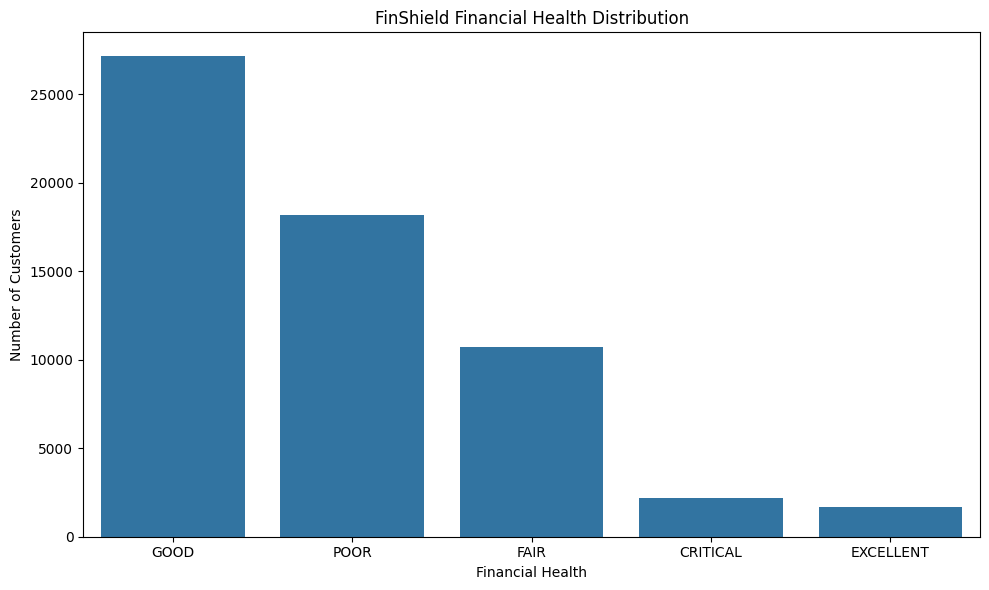

In [11]:
health_counts = (df["financial_health"].value_counts())

plt.figure(figsize=(10, 6))
sns.barplot(x=health_counts.index,y=health_counts.values)
plt.title("FinShield Financial Health Distribution")
plt.xlabel("Financial Health")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Insight:**

- The FinShield Financial Health distribution converts multiple risk signals, including credit, market, economic, and sentiment factors, into an executive-level view of customer financial condition.
- Customers classified as Excellent or Good indicate stronger financial positions, while Fair, Poor, and Critical customers represent progressively higher levels of financial vulnerability.
- A significant concentration of Poor or Critical customers would indicate increased portfolio exposure and the need for proactive financial-risk management.
- Using a unified financial-health classification enables management teams to prioritize customer interventions, allocate resources effectively, and monitor changes in portfolio quality.


##### Step 5: Save Customer FinShield Scores

In [12]:
out_cols = ["customer_id","credit_risk_score","market_risk_score","economic_risk_score",
            "sentiment_risk_score","final_risk_score","finshield_score","financial_health","primary_holding"]
df[out_cols].round(2).to_csv("outputs/finshield_scores.csv", index=False)
print("Saved")

Saved


### Phase 10: Explainable AI (SHAP)

##### Step 1: Prepare Customer Sample for SHAP Analysis

In [13]:
import shap
sample_idx = np.random.choice(df.index, 2000, replace=False)
X_sample = X.loc[sample_idx]
print(f"Explaining {len(X_sample)} customers.")

Explaining 2000 customers.


##### Step 2: Compute SHAP Values for High-Risk Customers

In [14]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

sv = np.array(shap_values)
high_idx = list(rf.classes_).index(2)  # class 2 = High
shap_high = sv[:, :, high_idx] if sv.ndim == 3 else shap_values[high_idx]
print("SHAP values computed, shape:", shap_high.shape)

SHAP values computed, shape: (2000, 21)


##### Step 3: Global Feature Importance Analysis

In [15]:
mean_abs_shap = np.abs(shap_high).mean(axis=0)
global_importance = pd.DataFrame({"feature": feature_cols+cat_cols, "mean_abs_shap": mean_abs_shap})
global_importance = global_importance.sort_values("mean_abs_shap", ascending=False)
global_importance["pct"] = (global_importance["mean_abs_shap"]/global_importance["mean_abs_shap"].sum()*100).round(1)
global_importance[["feature","pct"]].head(6)

,feature,pct
11,credit_score,53.0
13,late_payments,23.7
0,age,5.4
9,credit_usage_pct,4.2
1,employment_years,1.9
7,loan_amount,1.7


##### Step 4: Individual Customer Risk Explanation

In [16]:
pos = 0  # first customer in our sample
row_shap = shap_high[pos]
top_feat_idx = np.argsort(-np.abs(row_shap))[:3]

cust_id = df.loc[sample_idx[pos], "customer_id"]
print(f"Customer {cust_id} — top reasons:")
for fi in top_feat_idx:
    feat = (feature_cols+cat_cols)[fi]
    direction = "increases" if row_shap[fi] > 0 else "decreases"
    print(f"  {feat}: {direction} risk")

Customer C22628 — top reasons:
  credit_score: increases risk
  late_payments: decreases risk
  age: decreases risk


### Phase 11: Risk Monitoring & Segmentation

##### Step 1: Combine Fraud Flags with Health Scores

In [19]:
df = df.merge(txn2[["customer_id","is_flagged"]], on="customer_id", how="left")

def alert_level(row):
    if row["is_flagged"] == 1 and row["financial_health"] in ("POOR","CRITICAL"):
        return "PRIORITY ALERT"
    elif row["is_flagged"] == 1:
        return "FRAUD WATCH"
    elif row["financial_health"] == "CRITICAL":
        return "CREDIT ALERT"
    elif row["financial_health"] == "POOR":
        return "WATCHLIST"
    return "NORMAL"

df["alert_level"] = df.apply(alert_level, axis=1)
df["alert_level"].value_counts()

alert_level
NORMAL            38752
WATCHLIST         17894
CREDIT ALERT       2154
FRAUD WATCH         851
PRIORITY ALERT      349
Name: count, dtype: int64

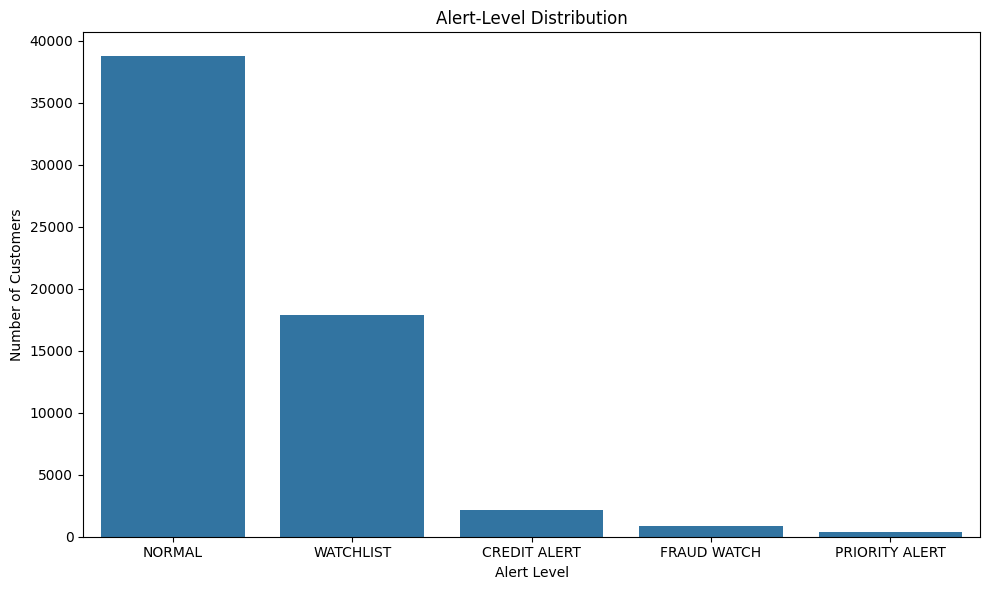

In [20]:
alert_counts = (df["alert_level"].value_counts())
plt.figure(figsize=(10, 6))
sns.barplot(x=alert_counts.index,y=alert_counts.values)
plt.title("Alert-Level Distribution")
plt.xlabel("Alert Level")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Insight:**

- The alert-level distribution shows the operational workload created by FinShield's risk-monitoring engine across Normal, Watch, Warning, and Critical cases.
- Normal cases represent customers requiring routine monitoring, while Watch and Warning cases identify customers whose financial conditions may require additional attention.
- Critical alerts represent the highest-priority cases and can help risk teams focus limited resources on customers with the greatest potential exposure.
- A structured alert hierarchy enables faster escalation, improves monitoring efficiency, and supports proactive intervention before emerging risks develop into severe financial problems.


##### Step 2: Group customers into behavioral segments

In [21]:
def segment(row):
    if row["investment_amount"] > row["monthly_income"]*3: return "Active Investor"
    if row["savings_amount"] > row["monthly_income"]*6: return "Strong Saver"
    if row["loan_amount"] > row["monthly_income"]*20: return "Highly Leveraged"
    if row["credit_card_count"] >= 3: return "Credit-Reliant"
    return "Standard"

df["segment"] = df.apply(segment, axis=1)
df["segment"].value_counts()

segment
Strong Saver        23267
Highly Leveraged    19256
Active Investor     13623
Standard             3083
Credit-Reliant        771
Name: count, dtype: int64

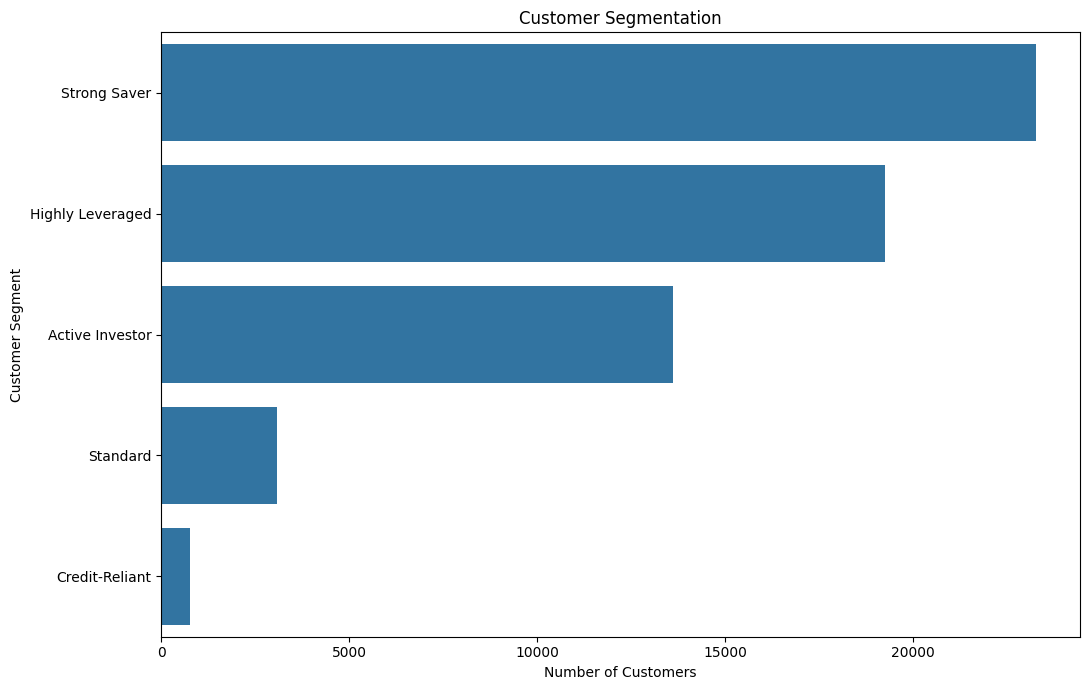

In [22]:
segment_counts = (
    df["segment"]
    .value_counts()
)

plt.figure(figsize=(11, 7))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Segmentation")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

**Insight:**

- Customer segmentation groups individuals with similar financial and risk characteristics, providing a clearer understanding of the different customer profiles within the FinShield portfolio.
- The size of each segment reveals where the largest customer populations are concentrated and helps identify groups that may require different financial strategies.
- Higher-risk or financially vulnerable segments can be targeted with preventive interventions, while financially stronger segments may present opportunities for retention and cross-selling.
- Combining customer segmentation with FinShield risk scores enables more personalized financial products, targeted interventions, and improved customer-management strategies.


### Phase 12: AI Recommendation Engine (Decision Center)

##### Step 1: Alert Level Assignment & Risk-Based Recommendations

In [23]:
def recommend(row):
    actions = []
    if row["financial_health"] in ("CRITICAL","POOR"):
        if row["loan_amount"] > row["monthly_income"]*15:
            actions.append("Reduce Loan Exposure")
        actions.append("Offer Financial Planning Session")
    if row["is_flagged"] == 1:
        actions.append("Manual Fraud Review")
    if row["savings_amount"] < row["monthly_income"]*2:
        actions.append("Encourage Emergency Savings Buffer")
    if not actions:
        actions.append("Continue Standard Monitoring")
    return "; ".join(actions)

df["recommended_actions"] = df.apply(recommend, axis=1)
df[["customer_id","financial_health","alert_level","recommended_actions"]].sample(5, random_state=1)

,customer_id,financial_health,alert_level,recommended_actions
15281,C25281,GOOD,NORMAL,Continue Standard Monitoring
21435,C31435,FAIR,NORMAL,Continue Standard Monitoring
44536,C54536,FAIR,NORMAL,Continue Standard Monitoring
13518,C23518,POOR,WATCHLIST,Reduce Loan Exposure; Offer Financial Planning...
47529,C57529,GOOD,NORMAL,Continue Standard Monitoring


SHAP values shape/type: <class 'numpy.ndarray'>
SHAP array shape: (2000, 21, 4)

Top SHAP Features:
                      Feature  SHAP Importance
0                credit_score         0.193056
1               late_payments         0.058586
2            credit_usage_pct         0.040164
3                         age         0.020733
4            employment_years         0.009914
5                   education         0.007490
6                 loan_amount         0.006261
7                      gender         0.005195
8                  emi_amount         0.004011
9             monthly_expense         0.002701
10             savings_amount         0.002184
11                 occupation         0.002006
12             monthly_income         0.001922
13          investment_amount         0.001635
14  transaction_count_monthly         0.001464


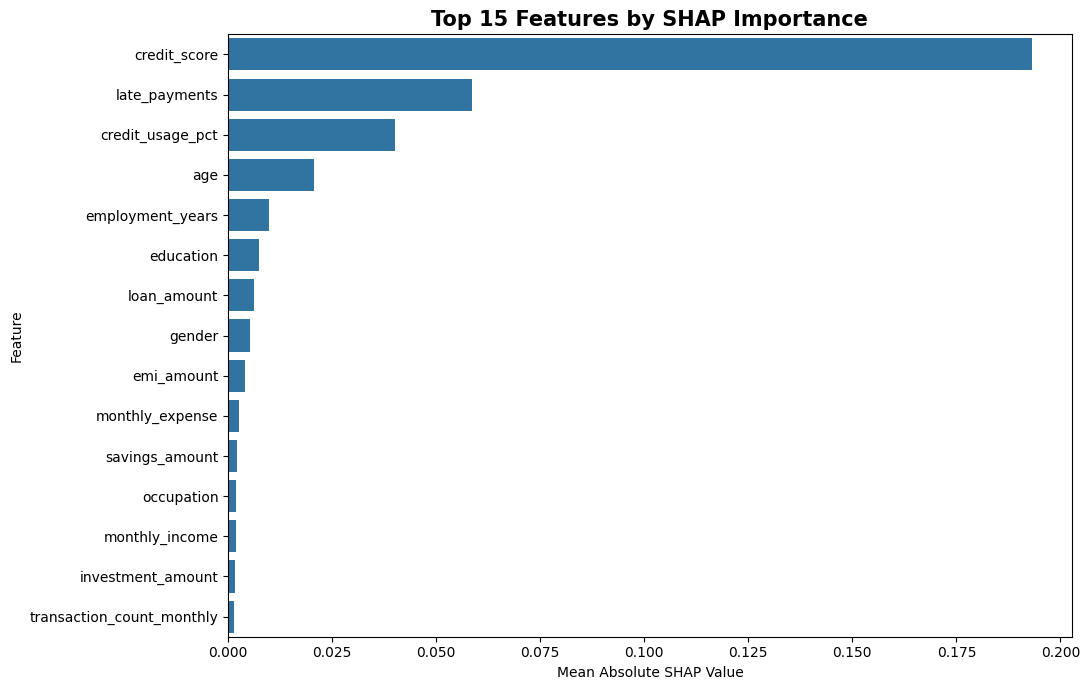

In [25]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_sample)

print("SHAP values shape/type:", type(shap_values))

if isinstance(shap_values, list):

    shap_importance = np.mean(
        [
            np.abs(values).mean(axis=0)
            for values in shap_values
        ],
        axis=0
    )

else:
    shap_values_array = np.asarray(shap_values)

    print("SHAP array shape:", shap_values_array.shape)

    if shap_values_array.ndim == 3:
        shap_importance = np.abs(
            shap_values_array
        ).mean(axis=(0, 2))

    elif shap_values_array.ndim == 2:
        shap_importance = np.abs(
            shap_values_array
        ).mean(axis=0)

    else:
        raise ValueError(
            f"Unexpected SHAP shape: {shap_values_array.shape}"
        )

shap_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "SHAP Importance": shap_importance
})

shap_df = (shap_df.sort_values("SHAP Importance",ascending=False).reset_index(drop=True))
print("\nTop SHAP Features:")
print(shap_df.head(15))
plt.figure(figsize=(11, 7))
sns.barplot(data=shap_df.head(15),x="SHAP Importance",y="Feature")
plt.title("Top 15 Features by SHAP Importance",fontsize=15,fontweight="bold")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Insight:**

- SHAP global importance provides an explainable view of the FinShield risk engine by showing which features have the greatest overall influence on model predictions.
- The most influential features help explain why certain customers receive higher or lower risk scores and provide transparency beyond the model's final classification.
- Comparing SHAP importance with Random Forest feature importance helps validate whether the model is consistently relying on meaningful financial indicators.
- Using SHAP explanations alongside risk predictions improves model transparency, supports more trustworthy financial decision-making, and helps risk teams understand the factors requiring corrective action.

##### Step 2: Save Final Monitoring & Decision Data

In [24]:
out_cols = ["customer_id","segment","alert_level","financial_health","finshield_score","is_flagged","recommended_actions"]
df[out_cols].to_csv("outputs/risk_monitoring_decisions.csv", index=False)
print("Saved & Part 3 Complete!")

Saved & Part 3 Complete!


### Phase 13: Business Insight

##### 1. Credit risk is concentrated in the Medium and High-risk segments

The Part 2 risk engine classified 28,062 customers as Medium-risk and 24,642 as High-risk, while 6,133 were Low-risk and 1,163 Critical. This indicates that the majority of the customer base requires active risk monitoring rather than being treated as uniformly low-risk.

##### 2. Credit score is the strongest predictor of customer risk

Random Forest feature importance shows that credit score contributes approximately 66.5% of model importance, followed by late payments at 11.5% and credit utilization at 7.1%. This confirms that credit quality and repayment behavior should remain central to FinShield's credit-risk strategy.

##### 3. Late-payment behavior provides an important early-warning signal

Late payments are the second-most important feature in the Random Forest model and account for approximately 23.7% of global SHAP importance in the Part 3 high-risk explanation. Increasing late-payment frequency can therefore be treated as a practical early indicator of deteriorating customer financial health.

##### 4. The customer portfolio contains a meaningful default-risk population

Part 1 identified 4,817 loan-default customers out of 60,000, resulting in an observed default rate of 8.03%. Defaulting customers also had a substantially lower average credit score than non-default customers, reinforcing the relationship between credit quality and repayment risk.

##### 5. Fraud monitoring adds a separate layer of financial protection

The Isolation Forest identified 1,200 customers as anomalies, representing 2% of the population, and achieved 92% recall on the injected extreme-spending test cases. This demonstrates the value of combining conventional credit-risk assessment with behavioral anomaly detection.

##### 6. Market risk varies materially across companies

Part 1 identified JOVIAN as the highest-volatility company at 0.0293 average 20-day volatility, while GRANITE was the lowest at 0.0123. Part 2 further classified companies into Low, Medium and High market-risk categories, enabling investment exposure to be incorporated into customer-level financial health.

##### 7. News sentiment provides an additional market-risk signal

The sentiment engine produced company-level impact scores ranging from negative to strongly positive, with INDUS at 0.182 and DELTA at 0.161 among the stronger positive impacts, while GRANITE recorded a slightly negative impact of -0.003. This allows FinShield to supplement price-based risk with qualitative market information.

##### 8. Macroeconomic conditions contribute a portfolio-wide risk component

The Part 3 engine calculated a portfolio-wide economic risk score of 43.8/100 using inflation, interest rates, unemployment and GDP growth. This ensures that customer-level risk is interpreted within the broader economic environment rather than relying only on individual financial behavior.

##### 9. FinShield Score converts multiple risk dimensions into one decision metric

The final FinShield Score combines credit risk, market risk, economic risk and sentiment risk using weighted components. The resulting 0–1000 health score makes complex analytical outputs easier for business users, relationship managers and decision-makers to interpret.

##### 10. Risk monitoring reveals a substantial intervention opportunity

Part 3 classified 17,894 customers as WATCHLIST, 2,154 as CREDIT ALERT, 851 as FRAUD WATCH and 349 as PRIORITY ALERT. This shows that FinShield can move beyond prediction toward operational risk management by prioritizing customers according to the severity and type of risk.

### Phase 14: Strategic Recommendations

##### 1. Prioritize proactive intervention for High and Critical-risk customers

FinShield should establish dedicated intervention workflows for customers classified as High or Critical risk. Credit restructuring, repayment planning and financial counselling can be prioritized before risk escalates into actual default.

##### 2. Build an early-warning system around credit score and late payments

Because credit score and late payments dominate model and SHAP importance, these variables should be monitored continuously. Significant deterioration should automatically trigger a customer review or risk-score refresh.

##### 3. Use fraud alerts alongside credit-risk scores# 3. Use fraud alerts alongside credit-risk scores

Fraud detection should not operate independently from the credit engine. Customers simultaneously showing anomalous transaction behavior and poor financial health should receive the highest investigation priority through the FinShield PRIORITY ALERT workflow.

##### 3. Use fraud alerts alongside credit-risk scores## 4. Introduce differentiated lending policies by risk segment

High-risk and highly leveraged customers should receive stricter exposure controls, while financially healthier customers can qualify for more flexible lending or credit-product offers. This creates a risk-adjusted approach instead of applying identical credit policies to every customer.

##### 3. Use fraud alerts alongside credit-risk scores# 5. Manage investment exposure using market-risk categories

Customers with investments linked to High-risk companies should receive additional portfolio-risk monitoring. FinShield can use the market-risk tags and forecasted returns to support diversification alerts and reduce excessive exposure to volatile holdings.

##### 3. Use fraud alerts alongside credit-risk scores## 6. Incorporate news sentiment into investment monitoring

Positive and negative company sentiment should be tracked alongside market volatility and expected return. Sudden deterioration in sentiment can be used as an additional trigger for portfolio review rather than relying exclusively on historical price behavior.

##### 7. Segment customers for personalized financial products

The segmentation engine identifies Strong Savers, Highly Leveraged, Active Investors, Credit-Reliant and Standard customers. Financial institutions can use these groups to design targeted products such as investment solutions for Active Investors, debt-management programs for Highly Leveraged customers and credit-health products for Credit-Reliant customers.

##### 8. Strengthen emergency-savings interventions

The recommendation engine already identifies customers with savings below two months of income. These customers should receive targeted guidance on building an emergency buffer, reducing financial vulnerability and improving resilience against unexpected expenses.

##### 9. Make explainability part of every high-risk decision

SHAP analysis should be integrated into the operational workflow so that risk officers can see the principal factors behind a customer's classification. This improves transparency, supports human review and makes model-driven decisions easier to communicate.

##### 10. Use FinShield as a continuous decision-support system

The system should evolve from periodic analysis into continuous monitoring of customer behavior, fraud signals, market conditions and economic indicators. The AI Assistant can then provide decision-oriented summaries, alerts and explanations instead of functioning only as a question-answering interface.

### Phase 15: Executive Summary, Future Scope & Conclusion

#### Executive Summary

FinShield AI Assistant is an integrated financial intelligence framework developed across three analytical stages: Data Foundation & Engineering, Machine Learning Engine, and Intelligence, Scoring & Explainability. The solution combines customer financial behavior, credit history, market information, economic indicators and financial-news sentiment into a unified risk-management framework.

Part 1 established the analytical foundation using 60,000 customers, 60,000 financial records, 60,000 credit records, 5,230 market records, 24 economic observations and 400 news records. The data was cleaned, processed, stored in a SQLite database and analyzed across customer demographics, credit behavior, financial health, market volatility and macroeconomic conditions.

Part 2 transformed these datasets into predictive intelligence. A four-level risk framework - Low, Medium, High and Critical -was developed using credit and financial behavior. The solution also introduced Isolation Forest-based anomaly detection, ARIMA market forecasting and TF-IDF-based financial sentiment classification. The fraud engine detected 92% of the injected extreme-spending cases, while the sentiment classifier reported 100% accuracy on its test split.

Part 3 converted these individual analytical components into the FinShield Score, a 0–1000 financial-health metric combining credit, market, economic and sentiment risk. The framework further introduced SHAP-based explainability, customer segmentation, alert prioritization and an AI recommendation engine.

The final system therefore moves beyond traditional credit scoring. It provides a broader financial-risk decision-support framework capable of identifying customer risk, monitoring abnormal behavior, incorporating market and economic conditions, explaining model outputs and recommending appropriate actions.

The FinShield AI Assistant extends this analytical framework into an interactive business interface, allowing users to interact with the underlying financial intelligence through an AI-driven assistant rather than relying exclusively on static notebooks and analytical outputs.

#### Future Scope

##### 1. Real-time financial data integration

Replace simulated or static market, economic and sentiment datasets with live data feeds from financial-market, economic and news APIs. This would allow FinShield scores and alerts to reflect current market conditions.

##### 2. Advanced fraud detection

Extend the Isolation Forest approach with supervised fraud models, graph-based transaction analysis and sequential behavioral models. Real transaction histories could improve detection of sophisticated fraud patterns beyond extreme-spending anomalies.

##### 3. Model optimization and validation

Perform systematic hyperparameter tuning, cross-validation and out-of-time validation for the risk models. Model performance should also be evaluated separately across Low, Medium, High and Critical classes using precision, recall and class-specific F1 scores.

##### 4. Improved credit-risk modelling

Future versions can introduce gradient boosting models such as LightGBM/XGBoost, calibrated probability estimates and ensemble modelling. This can improve predictive performance while maintaining probability-based risk scoring.

##### 5. Dynamic FinShield Score

The current FinShield framework can be extended from a static score to a continuously updating score. Changes in repayment behavior, transactions, investments, market volatility, sentiment and macroeconomic indicators could automatically update customer financial health.

##### 6. Advanced explainable AI

SHAP explanations can be expanded from global and individual feature importance to interactive customer-level explanations. Users could see exactly which financial factors increased or reduced their risk and how the score would change under alternative scenarios.

##### 7. Scenario and stress testing

FinShield can introduce simulations such as higher interest rates, increased unemployment, falling GDP growth or market corrections. This would help financial institutions estimate how customer portfolios may behave under adverse economic conditions.

##### 8. Portfolio-level intelligence

The system can be extended from customer-level scoring to portfolio-level risk aggregation. Financial institutions could monitor concentration risk, sector exposure, investment volatility, expected losses and emerging risk clusters.

##### 9. RAG-based financial knowledge assistant

The AI Assistant can be enhanced with Retrieval-Augmented Generation using approved financial policies, product documents, regulatory material and internal knowledge bases. This would improve grounded responses while reducing unsupported financial advice.

##### 10. Production deployment and governance

A production version should include model monitoring, data-drift detection, audit logs, role-based access, API-based model serving and secure secret management. Human approval should remain part of high-impact lending, fraud and financial decisions.

#### Conclusion

FinShield AI Assistant demonstrates how data engineering, machine learning, financial analytics, explainable AI and Generative AI can be combined into a single financial-risk intelligence platform.

The project begins with a structured data foundation and progresses through predictive risk classification, anomaly detection, market forecasting and financial sentiment analysis. These analytical components are then integrated into the FinShield Score, providing a unified measure of customer financial health across multiple dimensions.

A key strength of the solution is that it does not depend on a single financial indicator. Credit score and repayment behavior provide the core credit-risk signal, while fraud behavior, market volatility, sentiment and macroeconomic conditions provide additional context. SHAP further improves transparency by identifying the factors influencing high-risk predictions.

The final monitoring framework transforms predictions into business actions through Priority Alerts, Fraud Watch, Credit Alerts, Watchlists, customer segmentation and recommended interventions. This makes the project more than a machine-learning exercise; it becomes a decision-support architecture for financial risk management.

Overall, FinShield provides a strong foundation for a future production-grade FinTech platform. With real-time data, stronger model validation, dynamic scoring, advanced fraud analytics, scenario testing and a grounded financial AI assistant, the framework can evolve into a comprehensive Financial Risk & Intelligence Copilot for customers, analysts, lenders and investment teams.
